# HR Employee Attrition Analysis (Profile Attrition Analysis)

**Tujuan notebook ini:** menjawab business question ke-6: Profil risiko tinggi seperti apa yang terbentuk dari kombinasi faktor sebelumnya?

## 1. Setup & Load Data

Load data langsung dari MySQL supaya konsisten dengan sumber data yang sudah dinormalisasi.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
from scipy import stats

load_dotenv()

host = os.environ.get("DB_HOST")
user = os.environ.get("DB_USER")
password = os.environ.get("DB_PASSWORD")
database = os.environ.get("DB_NAME")

url_connect = f"mysql+pymysql://{user}:{password}@{host}/{database}"

engine = create_engine(url_connect)

In [2]:
query = """ SELECT
                e.attrition,
                e.over_time,
                e.years_at_company,
                e.years_with_curr_manager,
                e.years_since_last_promotion,
                c.monthly_income,
                c.stock_option_level,
                c.percent_salary_hike,
                ss.job_involvement,
                ss.job_satisfaction,
                ss.environment_satisfaction,
                ss.work_life_balance,
                ss.relationship_satisfaction
            FROM employees e
            JOIN compensation c ON e.employee_id = c.employee_id
            JOIN satisfaction_scores ss ON e.employee_id = ss.employee_id"""

with engine.connect() as koneksi:
    df = pd.read_sql(query, con=koneksi)

In [3]:
print(f"Jumlah baris & kolom: {df.shape}")
df.head()

Jumlah baris & kolom: (1470, 13)


,attrition,over_time,years_at_company,years_with_curr_manager,years_since_last_promotion,monthly_income,stock_option_level,percent_salary_hike,job_involvement,job_satisfaction,environment_satisfaction,work_life_balance,relationship_satisfaction
0,Yes,Yes,6,5,0,5993,0,11,3,4,2,1,1
1,No,No,10,7,1,5130,1,23,2,2,3,3,4
2,Yes,Yes,0,0,0,2090,0,15,2,3,4,3,2
3,No,Yes,8,0,3,2909,0,11,3,3,4,3,3
4,No,No,2,2,2,3468,1,12,3,2,1,3,4


### Menambahkan kolom `rasio_years`

In [4]:
df['rasio_years'] = df['years_since_last_promotion'] / df['years_at_company']
df['rasio_years'] = df['rasio_years'].fillna(0)
df['rasio_years'].head()

0    0.000
1    0.100
2    0.000
3    0.375
4    1.000
Name: rasio_years, dtype: float64

## 2. Preprocessing

Sebelum modeling, `attrition` dan `over_time` perlu diubah dari teks ("Yes"/"No") menjadi angka (1/0), karena `LogisticRegression` di scikit-learn hanya menerima input numerik. Encoding ini dilakukan **sebelum** train-test split — berbeda dari scaling nanti — karena pemetaan "Yes" → 1 dan "No" → 0 bersifat tetap dan tidak bergantung pada statistik data (seperti mean atau standar deviasi). Jadi tidak ada risiko *data leakage* meski dilakukan sebelum split.

In [5]:
from sklearn.preprocessing import OrdinalEncoder

label = OrdinalEncoder()
df[['attrition', 'over_time']] = label.fit_transform(df[['attrition', 'over_time']]).astype(int)
df.head()

,attrition,over_time,years_at_company,years_with_curr_manager,years_since_last_promotion,monthly_income,stock_option_level,percent_salary_hike,job_involvement,job_satisfaction,environment_satisfaction,work_life_balance,relationship_satisfaction,rasio_years
0,1,1,6,5,0,5993,0,11,3,4,2,1,1,0.000
1,0,0,10,7,1,5130,1,23,2,2,3,3,4,0.100
2,1,1,0,0,0,2090,0,15,2,3,4,3,2,0.000
3,0,1,8,0,3,2909,0,11,3,3,4,3,3,0.375
4,0,0,2,2,2,3468,1,12,3,2,1,3,4,1.000


Data dibagi menjadi data latih (train) dan data uji (test) terlebih dahulu, **baru kemudian** di-standardisasi — urutan ini penting untuk menghindari *data leakage*. `StandardScaler` menghitung mean dan standar deviasi dari data yang di-fit, kalau proses fit dilakukan pada seluruh data (termasuk data test) sebelum split, informasi statistik dari data test akan "bocor" ke proses training, membuat evaluasi model nanti terlihat lebih baik dari performa sebenarnya pada data yang benar-benar belum pernah dilihat model. Karena itu, `scaler.fit_transform()` hanya diterapkan pada `X_train`, sedangkan `X_test` cukup di-`transform()` memakai parameter (mean, std) yang sudah dipelajari dari data train saja.

Standardisasi sendiri diperlukan karena skala tiap fitur sangat berbeda (`monthly_income` dalam ribuan, `job_satisfaction` cuma 1-4) — tanpa standardisasi, besar-kecilnya koefisien logistic regression nanti tidak bisa dibandingkan secara adil antar fitur untuk menentukan mana yang paling berpengaruh.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('attrition', axis=1)
y = df['attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_std = scaler.transform(X)

In [7]:
stay = (y_train.value_counts()[0] / y_train.shape)[0]
leave = (y_train.value_counts()[1] / y_train.shape)[0]

print("===============TRAIN=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

stay = (y_test.value_counts()[0] / y_test.shape)[0]
leave = (y_test.value_counts()[1] / y_test.shape)[0]

print("===============TEST=================")
print(f"Staying Rate: {stay * 100:.2f}%")
print(f"Leaving Rate: {leave * 100 :.2f}%")

===============TRAIN=================
Staying Rate: 83.87%
Leaving Rate: 16.13%
===============TEST=================
Staying Rate: 83.90%
Leaving Rate: 16.10%


Sebelum membangun model, perlu dicek dulu apakah ada multikolinearitas antar fitur — terutama mengingat 3 variabel tenure di Q4 sudah diketahui saling berkorelasi cukup tinggi. Digunakan Variance Inflation Factor (VIF), dengan kolom konstanta (`add_constant`) ditambahkan terlebih dahulu agar perhitungan valid.

In [8]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

x_konstan = sm.add_constant(X_train)

vif_data = pd.DataFrame()
vif_data['feature'] = x_konstan.columns
vif_data['VIF'] = [variance_inflation_factor(x_konstan.values, i) 
                   for i in range(x_konstan.shape[1])]
vif_data

,feature,VIF
0,const,73.506677
1,over_time,1.014144
2,years_at_company,4.284733
3,years_with_curr_manager,2.507868
4,years_since_last_promotion,3.734862
5,monthly_income,1.409177
6,stock_option_level,1.008156
7,percent_salary_hike,1.014003
8,job_involvement,1.013318
9,job_satisfaction,1.002948


Ketiga variabel tenure (`years_at_company` = 4,28, `years_since_last_promotion` = 3,73, `years_with_curr_manager` = 2,50) menunjukkan VIF yang jauh lebih tinggi dibanding fitur lain yang hampir semuanya mendekati 1,0 — konsisten dengan korelasi tinggi yang sudah ditemukan di heatmap Q4. Meski begitu, nilai VIF tertinggi (4,28) masih di bawah ambang batas 5 yang umum dianggap kritis, sehingga belum tergolong multikolinearitas parah — namun cukup untuk diwaspadai saat menginterpretasikan koefisien ketiga variabel ini secara individual nanti.

## 3. Bangun Model

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def evaluate(model, X_train, X_test, y_train, y_test):
    y_test_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    print("TRAINING RESULTS: \n==================================")
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_train, y_train_pred)}")
    print("==================================")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_train, y_train_pred)}")
    print("==================================")
    print(f"CLASSIFICATION REPORT:\n{classification_report(y_train, y_train_pred)}")

    print("TESTING RESULTS: \n==================================")
    print(f"CONFUSION MATRIX:\n{confusion_matrix(y_test, y_test_pred)}")
    print("==================================")
    print(f"ACCURACY SCORE:\n{accuracy_score(y_test, y_test_pred)}")
    print("==================================")
    print(f"CLASSIFICATION REPORT:\n{classification_report(y_test, y_test_pred)}")

Logistic regression dipilih sebagai model untuk Q6 karena dua alasan utama. Pertama, target (`attrition`) bersifat biner (Yes/No), yang memang jadi kasus penggunaan utama logistic regression. Kedua, dan lebih penting — tujuan Q6 bukan sekadar memprediksi attrition seakurat mungkin, tapi **memahami faktor mana yang paling berpengaruh** setelah mengontrol variabel lain sekaligus. Logistic regression menghasilkan koefisien yang bisa langsung diinterpretasikan sebagai arah dan kekuatan pengaruh tiap fitur (setelah distandarisasi), berbeda dari model yang lebih kompleks (misalnya Random Forest atau XGBoost) yang meski berpotensi lebih akurat, koefisien/kepentingan fiturnya tidak seintuitif dan butuh teknik tambahan (seperti SHAP) untuk diinterpretasikan dengan cara yang sama. Karena tujuan proyek ini condong ke *explanatory* (menjelaskan faktor) dibanding murni *predictive* (memaksimalkan akurasi), logistic regression jadi pilihan yang paling sesuai dan proporsional untuk saat ini.

In [10]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', solver='liblinear')
lr_model.fit(X_train_std, y_train)

evaluate(lr_model, X_train_std, X_test_std, y_train, y_test)

TRAINING RESULTS: 
CONFUSION MATRIX:
[[641 222]
 [ 40 126]]
ACCURACY SCORE:
0.7453838678328474
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.94      0.74      0.83       863
           1       0.36      0.76      0.49       166

    accuracy                           0.75      1029
   macro avg       0.65      0.75      0.66      1029
weighted avg       0.85      0.75      0.78      1029

TESTING RESULTS: 
CONFUSION MATRIX:
[[274  96]
 [ 22  49]]
ACCURACY SCORE:
0.7324263038548753
CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.93      0.74      0.82       370
           1       0.34      0.69      0.45        71

    accuracy                           0.73       441
   macro avg       0.63      0.72      0.64       441
weighted avg       0.83      0.73      0.76       441



Model mencapai recall 0,69 untuk kelas attrition "Yes" pada data test — artinya model berhasil mengidentifikasi 69% karyawan yang benar-benar keluar. Precision-nya rendah (0,34), yang berarti model juga banyak "salah alarm" (memprediksi karyawan akan keluar padahal bertahan). Trade-off ini sengaja diambil dengan `class_weight='balanced'`, karena dari sisi bisnis, gagal mendeteksi karyawan yang berisiko keluar (false negative) biasanya lebih mahal konsekuensinya dibanding salah menandai karyawan yang sebenarnya aman (false positive).

In [11]:
koefisien = lr_model.coef_[0]
nama_fitur = X.columns

tabel_koefisien = pd.DataFrame({
    'fitur' : nama_fitur,
    'koefisien_asli' : koefisien
})

tabel_koefisien['nilai_absolut'] = tabel_koefisien['koefisien_asli'].abs()

tabel_koefisien = tabel_koefisien.sort_values(by='nilai_absolut', ascending=False)
tabel_koefisien = tabel_koefisien.drop(columns=['nilai_absolut'])
tabel_koefisien

,fitur,koefisien_asli
0,over_time,0.726965
4,monthly_income,-0.625849
3,years_since_last_promotion,0.569111
2,years_with_curr_manager,-0.542723
8,job_satisfaction,-0.420920
5,stock_option_level,-0.405276
9,environment_satisfaction,-0.358141
7,job_involvement,-0.301034
10,work_life_balance,-0.238229
12,rasio_years,-0.208101


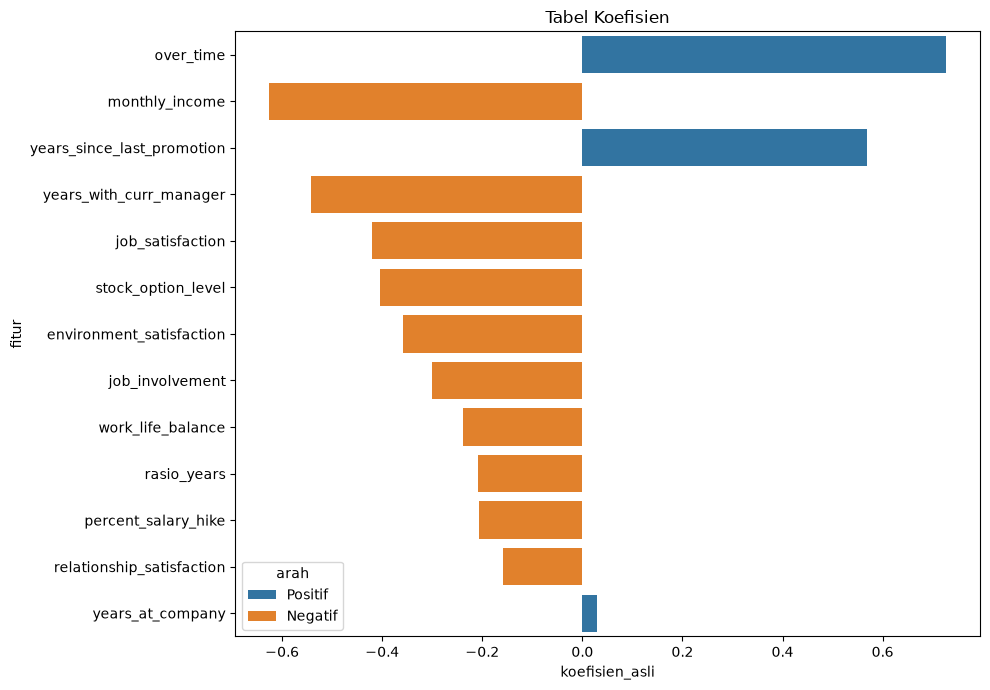

In [12]:
tabel_koefisien['arah'] = tabel_koefisien['koefisien_asli'].apply(lambda x: 'Positif' if x > 0 else 'Negatif')

plt.figure(figsize=(10, 7))
sns.barplot(tabel_koefisien, x='koefisien_asli', y='fitur', hue='arah')
plt.title("Tabel Koefisien")
plt.tight_layout()
plt.show()

`over_time` menjadi fitur dengan pengaruh terbesar (koefisien 0,73), diikuti `monthly_income` (-0,63) dan `years_since_last_promotion` (0,57). Namun, dua variabel tenure (`years_since_last_promotion` dan `years_at_company`) perlu dibaca hati-hati, karena hasil VIF sebelumnya menunjukkan ketiganya saling berkorelasi, sehingga koefisien individualnya bisa menjadi tidak stabil. Ini terkonfirmasi di sini — `years_at_company` yang di Q4 terbukti paling kuat secara univariate (rank-biserial 0,2979), di model gabungan ini koefisiennya nyaris nol (0,029, urutan terakhir), sementara `years_since_last_promotion` yang tadinya paling lemah (rank-biserial 0,0803) justru melonjak jadi salah satu yang terkuat. Fenomena ini adalah kombinasi dari korelasi antar variabel tenure dan regularisasi L2 bawaan `LogisticRegression`, yang bisa membuat bobot "terserap" tidak merata di antara fitur-fitur yang saling berkorelasi. Karena itu, interpretasi individual pada ketiga variabel tenure sebaiknya dilakukan dengan hati-hati, dan lebih diutamakan melihat hasil univariate (Q4) untuk masing-masing variabel secara terpisah.

## 4. Feature Importance & Profil Risiko Tinggi

### Pendekatan 1: Kombinasi Aturan Sederhana

Menggunakan 3 fitur dengan koefisien absolut terbesar yang stabil (tidak terpengaruh isu multikolinearitas tenure): `over_time`, `monthly_income`, dan `job_satisfaction`. Profil risiko tinggi didefinisikan sebagai karyawan yang overtime, berpenghasilan di bawah kuartil 1 (25%), dan memiliki job satisfaction rendah (skala 1-2 dari 4).

In [13]:
high_risk = (
    (df['over_time'] == 1) &
    (df['monthly_income'] < df['monthly_income'].quantile(0.25)) &
    (df['job_satisfaction'] <= 2)
)

high_risk_employee = df[high_risk]
rata_rata_karyawan = high_risk_employee['attrition'].mean() * 100
print(f"Jumlah karyawan yang masuk ke profil risiko tinggi: {len(high_risk_employee)}")
print(f"Attrition rate pada profil risiko tinggi: {rata_rata_karyawan:.2f}")
print(f"Attrition rate perusahaan: {df['attrition'].mean() * 100:.2f}")

Jumlah karyawan yang masuk ke profil risiko tinggi: 44
Attrition rate pada profil risiko tinggi: 65.91
Attrition rate perusahaan: 16.12


Karyawan dengan kombinasi ketiga kriteria ini (44 orang, sekitar 3% dari total karyawan) memiliki attrition rate sebesar **65,91%** — lebih dari 4 kali lipat rata-rata perusahaan (16,12%).

### Pendekatan 2: Berbasis Probabilitas Prediksi Model

Menggunakan seluruh probabilitas prediksi model (`predict_proba`) untuk membagi seluruh karyawan menjadi 10 tingkatan risiko (risk_level 1-10, dari yang paling rendah ke paling tinggi), lalu memprofilkan karakteristik tiap tingkatan.

In [14]:
probabilitas = lr_model.predict_proba(X_std)[:, 1]
df['probabilitas'] = probabilitas
df['risk_level'] = pd.qcut(df['probabilitas'], 10, labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).astype(int)
total = len(df)


df.groupby('risk_level').agg(
    attrition_rate_local = ('attrition', lambda x: round(x.mean() * 100, 2)),
    over_time_rate = ('over_time', lambda x: round(x.mean() * 100, 2)),
    monthly_income_mean = ('monthly_income', 'mean'),
    job_satisfaction_mean = ('job_satisfaction', 'mean')
)

,attrition_rate_local,over_time_rate,monthly_income_mean,job_satisfaction_mean
risk_level,,,,
1,3.40,4.76,12394.435374,3.183673
2,2.04,5.44,8426.877551,3.244898
3,4.08,10.20,7141.687075,2.959184
4,4.08,9.52,6527.884354,2.748299
5,6.12,13.61,5973.421769,2.755102
6,14.97,20.41,5273.517007,2.802721
7,14.97,27.89,5546.401361,2.578231
8,22.45,40.82,4989.945578,2.380952
9,32.65,64.63,4714.115646,2.489796


Attrition rate meningkat hampir monoton dari 3,40% (risk_level 1) menjadi 56,46% (risk_level 10) — kenaikan lebih dari 16 kali lipat, menunjukkan model mampu memisahkan karyawan berisiko tinggi dan rendah dengan cukup baik. Pola ini konsisten dengan arah koefisien: `over_time_rate` naik tajam (4,76% → 85,71%), sementara `monthly_income_mean` (12.394 → 4.041) dan `job_satisfaction_mean` (3,18 → 2,14) menurun seiring naiknya level risiko. Menariknya, profil risk_level 10 (147 orang, attrition rate 56,46%) justru kalah "tajam" dibanding profil manual dari Pendekatan 1 (44 orang, attrition rate 65,91%).

## Kesimpulan

Model logistic regression berhasil mengidentifikasi pola attrition dengan recall 69% pada data test, dengan `over_time`, `monthly_income`, dan `job_satisfaction` sebagai fitur-fitur yang paling stabil dan berpengaruh. Uji VIF mengonfirmasi bahwa ketiga variabel tenure (`years_at_company`, `years_since_last_promotion`, `years_with_curr_manager`) saling berkorelasi moderate, yang menjelaskan mengapa urutan pengaruhnya berubah signifikan dibanding hasil univariate di Q4 — sebuah temuan penting yang menunjukkan analisis satu-per-satu dan analisis gabungan perlu dibaca bersamaan, bukan saling menggantikan.

Dua pendekatan digunakan untuk membangun profil risiko tinggi. **Pendekatan berbasis aturan sederhana** (kombinasi overtime, penghasilan rendah, dan job satisfaction rendah) menghasilkan kelompok kecil namun sangat terkonsentrasi: 44 karyawan (3% dari total) dengan attrition rate 65,91% — lebih dari 4 kali lipat rata-rata perusahaan. **Pendekatan berbasis probabilitas model** menunjukkan bahwa seluruh karyawan bisa dipetakan ke dalam spektrum risiko yang jelas, dari 3,40% (risiko terendah) hingga 56,46% (risiko tertinggi), dengan pola yang konsisten pada seluruh fitur pendukung.

**Catatan batasan**: seperti seluruh business question sebelumnya, dataset ini bersifat cross-sectional, sehingga hasil analisis menunjukkan asosiasi dan pola prediktif, bukan hubungan sebab-akibat yang pasti.

**Implikasi praktis**: HR dapat menggunakan kombinasi kriteria sederhana (overtime + penghasilan rendah + job satisfaction rendah) sebagai *early warning* yang mudah diimplementasikan tanpa perlu model machine learning, sambil mempertimbangkan model probabilitas untuk pemantauan risiko yang lebih menyeluruh dan bertingkat di seluruh populasi karyawan.